# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample. 

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [6]:
N_Max=550000
N_Train=500000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train=np.array(Train_Sample[VarNames[1:]])
y_Train=np.array(Train_Sample["signal"])

X_Test=np.array(Test_Sample[VarNames[1:]])
y_Test=np.array(Test_Sample["signal"])


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs. 
* Compare the performance on training versus test sample. Are you over training?

In [10]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss Plot, monitors the optimization objective and tracks if the model is still learning
    ax1.plot(history.history['loss'], label='Train')
    ax1.plot(history.history['val_loss'], label='Validation')
    ax1.set_title('Model Loss')
    ax1.set_ylabel('Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    
    # Accuracy Plot, Monitors the classification success rate
    ax2.plot(history.history['accuracy'], label='Train')
    ax2.plot(history.history['val_accuracy'], label='Validation')
    ax2.set_title('Model Accuracy')
    ax2.set_ylabel('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    
    plt.show()

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

Training model for: Raw


/home/abrar/Data-3402/DATA3402.Spring.2026/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 443us/step
Training model for: Features


/home/abrar/Data-3402/DATA3402.Spring.2026/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 429us/step
Training model for: Combined


/home/abrar/Data-3402/DATA3402.Spring.2026/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 401us/step


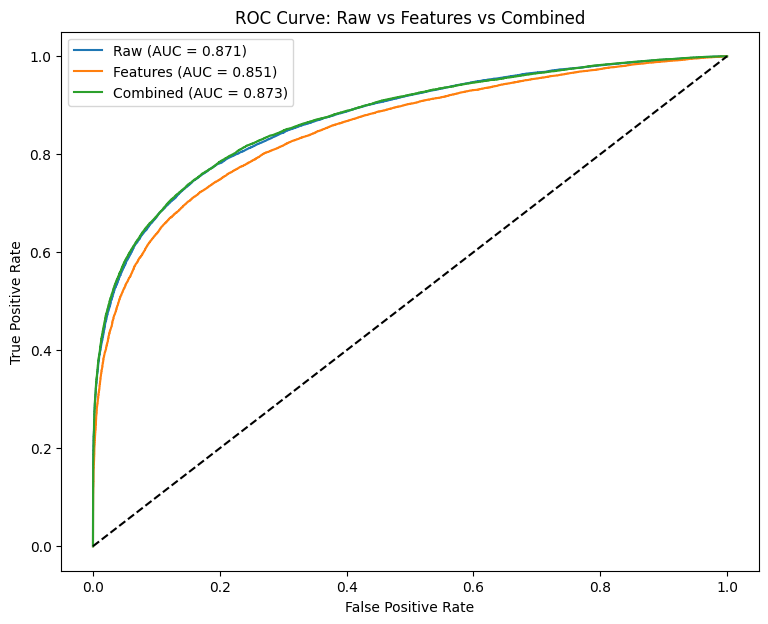

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.layers import Input

# Defining the subsets of data, partitioning data into raw, features, and combined sets
sets = {
    "Raw": (X_Train[:, :10], X_Test[:, :10]),
    "Features": (X_Train[:, 10:], X_Test[:, 10:]),
    "Combined": (X_Train, X_Test)
}

plt.figure(figsize=(9, 7))

for name, (train_data, test_data) in sets.items():
    print(f"Training model for: {name}")
    
    # Model definition using the Input object to specify feature dimensions
    model = Sequential([
        Dense(64, activation='relu', input_shape=(train_data.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid') # Sigmoid for binary classification
    ])
    
    # Compiling the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Training with a large batch size for computational efficiency on the 500k sample
    model.fit(train_data, y_Train, epochs=10, batch_size=1024, verbose=0)
    
    # Post-training evaluation and ROC generation
    y_pred = model.predict(test_data).ravel()
    fpr, tpr, _ = roc_curve(y_Test, y_pred)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')

# Visualizing the trade-off between True Positive and False Positive rates
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Raw vs Features vs Combined')
plt.legend()
plt.show()

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

Training Shallow...
Plots for Shallow:


<Figure size 800x600 with 0 Axes>

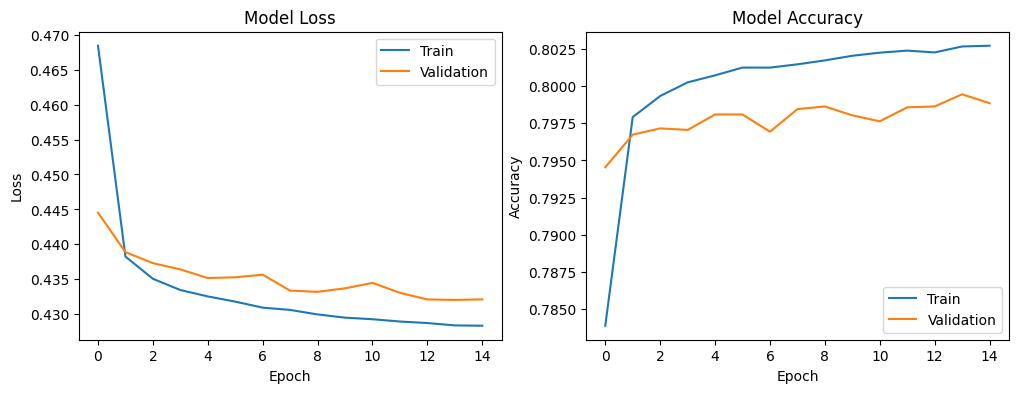

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 422us/step
Training Deep_Dropout...
Plots for Deep_Dropout:


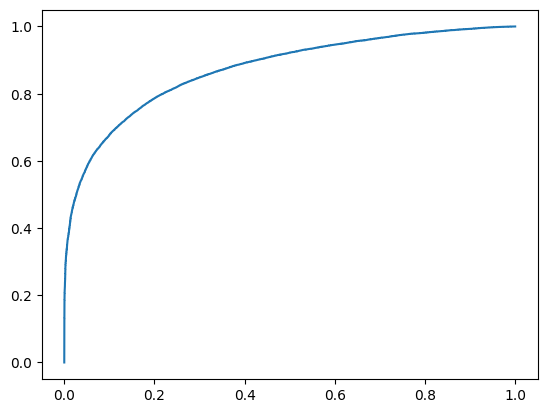

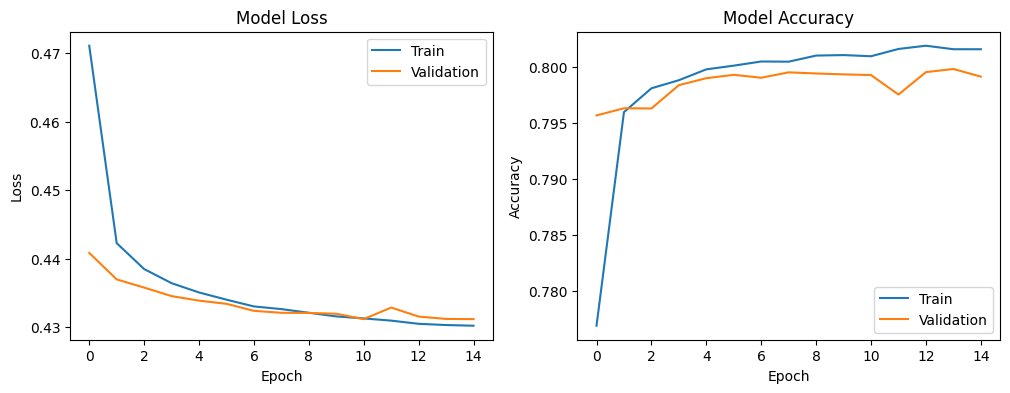

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 446us/step
Training RMSprop_Opt...
Plots for RMSprop_Opt:


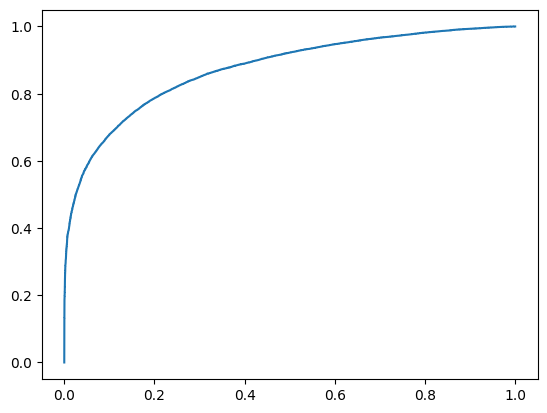

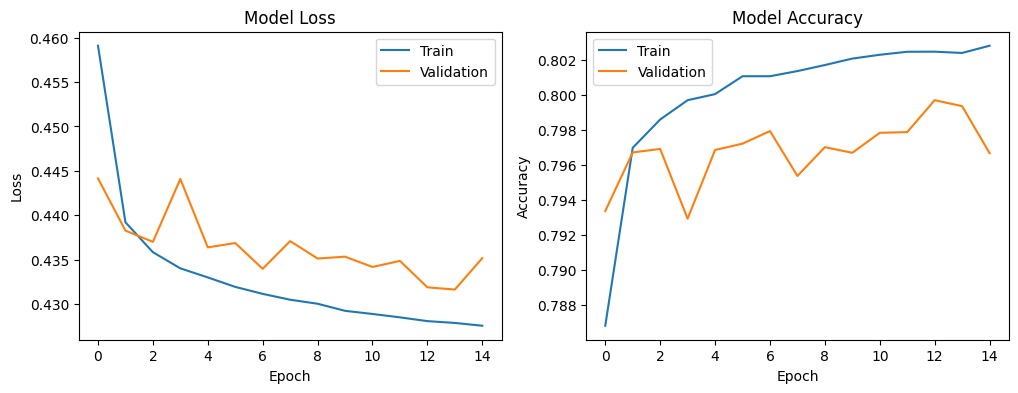

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 445us/step


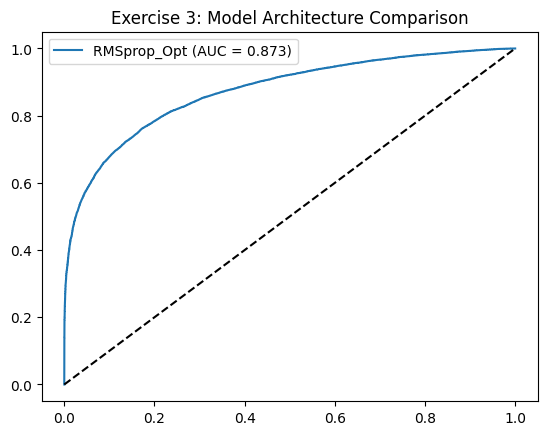

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# Dictionary to store ROC data for Exercise 4
ex3_results = {}

# Model 1, shallow baseline: This architecture tests performance with a single high-capacity hidden layer and sees if deeper networks would add value to the dataset.
model_1 = Sequential([
    Input(shape=(X_Train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model 2, Deep with Dropout: This model increases depth to capture complex non-linearities.
# dropout is introduced as a regularization technique to lessen the risk of overtraining
model_2 = Sequential([
    Input(shape=(X_Train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2), # Randomly shuts off 20% of neurons to prevent overtraining
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model 3, Different Optimizer (RMSprop), explores the impact of the RMSprop optimizer compared to Adam.
# RMSprop can sometimes converge differently on high energy physics data.
model_3 = Sequential([
    Input(shape=(X_Train.shape[1],)),
    Dense(100, activation='relu'),
    Dense(50, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_3.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

# Training and plotting
models = {"Shallow": model_1, "Deep_Dropout": model_2, "RMSprop_Opt": model_3}

plt.figure(figsize=(8, 6))
for name, m in models.items():
    print(f"Training {name}...")
    history = m.fit(X_Train, y_Train, epochs=15, batch_size=1024, validation_data=(X_Test, y_Test), verbose=0)
    
    # Run the plot_history function from Ex 1 to check for ivertraining
    print(f"Plots for {name}:")
    plot_history(history)
    
    y_pred = m.predict(X_Test).ravel()
    fpr, tpr, _ = roc_curve(y_Test, y_pred) # Compute the ROC curve metrics and the AUC.
    auc_score = auc(fpr, tpr)
    ex3_results[name] = (fpr, tpr, auc_score) # Save for comparison
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Exercise 3: Model Architecture Comparison')
plt.legend()
plt.show()

## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


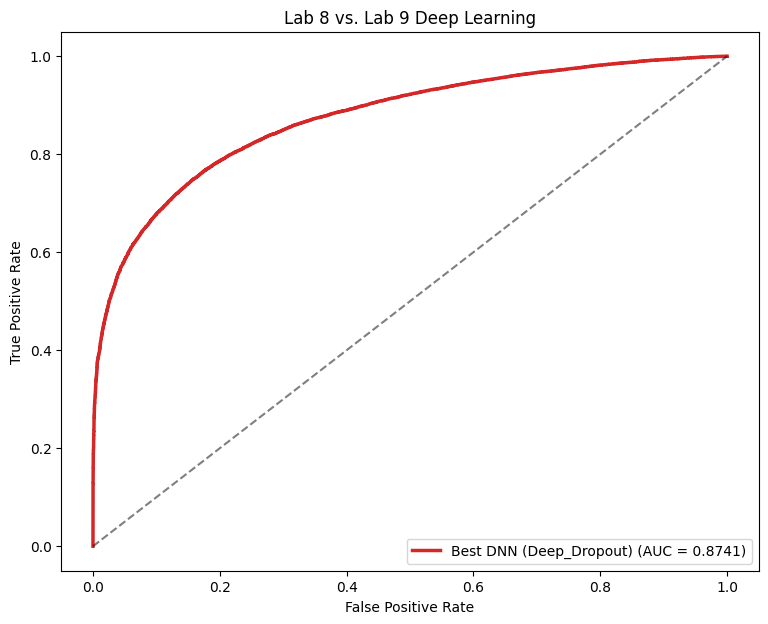

In [29]:
plt.figure(figsize=(9, 7))

# fpr_old and tpr_old variables are populated from lab 8

# Automatically selects the model with the highest AUC score
best_key = max(ex3_results, key=lambda k: ex3_results[k][2])
fpr_dnn, tpr_dnn, auc_dnn = ex3_results[best_key]

# Identify model with highest AUC from the results dictionary
plt.plot(fpr_dnn, tpr_dnn, label=f'Best DNN ({best_key}) (AUC = {auc_dnn:.4f})', 
         color='tab:red', linewidth=2.5)

# Plot formatting
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Lab 8 vs. Lab 9 Deep Learning')
plt.legend(loc='lower right')
plt.show()